# Aula 3 — Engenharia de modelos com Dask e MLflow

Esta é uma versão aprimorada e distribuída do exercício de engenharia de modelos. Ela mantém a finalidade didática do notebook original — engenharia e seleção de atributos, ajuste de um classificador, avaliação, rastreamento e persistência — e corrige o uso do conjunto de teste durante a seleção de hiperparâmetros.

**Regra metodológica:** o conjunto de teste é separado antes do tuning e só é consultado uma vez, depois que o melhor pipeline já foi escolhido exclusivamente pela validação cruzada em treino.

## Arquitetura da execução

```text
WS-Dell-Ubuntu (Jupyter + cliente + MLflow + artefatos)
                 |
                 | tcp://192.168.50.171:8796
                 v
         Dask Scheduler :8796
         Dashboard      :8797
            /       |       \
           v        v        v
     PowerEdge   Beelink   note-asus
     4 × 1 CPU   8 × 1 CPU 8 × 1 CPU
```

O CSV é carregado apenas no host principal. O backend Dask do Joblib distribui os ajustes da validação cruzada e usa `scatter=[X_train, y_train]` para não retransmitir os mesmos dados em cada tarefa. O Random Forest usa um único thread por ajuste; o paralelismo acontece entre candidatos e folds.

## 1. Importações

As funções estão agrupadas por responsabilidade e as mensagens operacionais usam `logging`. O MLflow é importado somente depois do treinamento, evitando serializar dependências exclusivas do host principal. Avisos continuam visíveis; durante o dispatch Dask são omitidos apenas filtros cujas classes não existem no ambiente mínimo dos workers.

In [1]:
from __future__ import annotations

import hashlib
import importlib.metadata as importlib_metadata
import json
import logging
import os
import platform
import socket
import sys
import time
import warnings
from pathlib import Path
from typing import Any

import cloudpickle
import dask
import distributed
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import seaborn as sns
import sklearn
import skops.io as sio
from dask.distributed import Client
from IPython.display import display
from scipy.stats import randint
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    RandomizedSearchCV,
    RepeatedStratifiedKFold,
    train_test_split,
)
from sklearn.pipeline import Pipeline

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    force=True,
)
logger = logging.getLogger("engenharia_modelos")
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_context("notebook")

## 2. Configuração central e caminhos

O orçamento padrão `extended` avalia 500 candidatos, totalizando 5.000 fits com CV 5×2. Use `MODEL_SEARCH_BUDGET=quick|standard|extended|exhaustive` ou `MODEL_SEARCH_N_ITER` para controle direto. Variáveis com prefixo `MODEL_` permitem ajustar custo sem editar o notebook. A raiz do projeto é localizada tanto quando o Jupyter inicia na raiz quanto quando inicia na pasta da aula.

In [2]:
def find_project_dir(start: Path) -> Path:
    """Localiza a raiz que contém o CSV usado pelo exercício."""
    resolved = start.resolve()
    for candidate in (resolved, *resolved.parents):
        if (candidate / "data" / "heart_disease_uci_preprocessed.csv").is_file():
            return candidate
    raise FileNotFoundError(
        "Não foi possível localizar data/heart_disease_uci_preprocessed.csv "
        f"a partir de {resolved}."
    )


def env_flag(name: str, default: bool = False) -> bool:
    """Lê uma variável de ambiente booleana."""
    raw = os.getenv(name)
    return default if raw is None else raw.strip().lower() in {"1", "true", "yes", "sim"}


RANDOM_STATE = 42
TEST_SIZE = 0.20
N_SPLITS = int(os.getenv("MODEL_CV_SPLITS", "5"))
N_REPEATS = int(os.getenv("MODEL_CV_REPEATS", "2"))

SEARCH_BUDGETS = {
    "quick": 25,
    "standard": 200,
    "extended": 500,
    "exhaustive": 1_000,
}
SEARCH_BUDGET = os.getenv("MODEL_SEARCH_BUDGET", "extended").strip().lower()
if SEARCH_BUDGET not in SEARCH_BUDGETS:
    raise ValueError(
        f"MODEL_SEARCH_BUDGET={SEARCH_BUDGET!r} inválido. "
        f"Escolha entre {sorted(SEARCH_BUDGETS)}."
    )
N_ITER = int(
    os.getenv(
        "MODEL_SEARCH_N_ITER",
        str(SEARCH_BUDGETS[SEARCH_BUDGET]),
    )
)
TOTAL_CV_FITS = N_ITER * N_SPLITS * N_REPEATS
SCORING = os.getenv("MODEL_SCORING", "roc_auc")
POS_LABEL = 1
LOCAL_N_JOBS = int(
    os.getenv(
        "MODEL_LOCAL_N_JOBS",
        str(min(4, max(1, (os.cpu_count() or 2) - 1))),
    )
)

DASK_SCHEDULER = os.getenv(
    "MODEL_DASK_SCHEDULER",
    "tcp://192.168.50.171:8796",
)
DASK_TIMEOUT = os.getenv("MODEL_DASK_TIMEOUT", "10s")
RUN_CLUSTER_DIAGNOSTIC = env_flag("MODEL_RUN_CLUSTER_DIAGNOSTIC", False)

EXPERIMENT_NAME = os.getenv(
    "MODEL_MLFLOW_EXPERIMENT",
    "aula3_engenharia_modelos_distribuida",
)
RUN_NAME = os.getenv("MODEL_MLFLOW_RUN_NAME", "random_forest_randomized_search")
SAVE_JOBLIB_COPY = env_flag("MODEL_SAVE_JOBLIB", True)

PROJECT_DIR = find_project_dir(Path.cwd())
OUTPUT_ROOT = Path(os.getenv("MODEL_OUTPUT_DIR", str(PROJECT_DIR))).expanduser().resolve()
DATA_PATH = PROJECT_DIR / "data" / "heart_disease_uci_preprocessed.csv"
MODELS_DIR = OUTPUT_ROOT / "models"
ARTIFACTS_DIR = OUTPUT_ROOT / "artifacts"
MLFLOW_DB_PATH = OUTPUT_ROOT / "mlflow.db"
MLFLOW_ARTIFACTS_DIR = OUTPUT_ROOT / "mlflow-artifacts"
DEFAULT_MLFLOW_TRACKING_URI = f"sqlite:///{MLFLOW_DB_PATH}"
MLFLOW_TRACKING_URI = os.getenv("MLFLOW_TRACKING_URI", DEFAULT_MLFLOW_TRACKING_URI)

TARGET_COLUMN = "target"
DROP_COLUMNS = ("id", "dataset")
CLASS_NAMES = {0: "Sem doença", 1: "Com doença"}

SKOPS_TRUSTED_TYPES = [
    "numpy.dtype",
    "sklearn.feature_selection._univariate_selection.f_classif",
]

EXPECTED_CORE_VERSIONS = {
    "Python": "3.10.12",
    "numpy": "2.2.6",
    "pandas": "2.3.3",
    "scipy": "1.15.3",
    "scikit-learn": "1.7.2",
    "joblib": "1.5.3",
    "cloudpickle": "3.1.2",
    "dask": "2026.7.1",
    "distributed": "2026.7.1",
}

for directory in (MODELS_DIR, ARTIFACTS_DIR, MLFLOW_ARTIFACTS_DIR):
    directory.mkdir(parents=True, exist_ok=True)

logger.info("Projeto: %s", PROJECT_DIR)
logger.info("Dados: %s", DATA_PATH)
logger.info("Saídas: %s", OUTPUT_ROOT)
logger.info(
    "Scoring=%s | orçamento=%s | CV=%sx%s | candidatos=%s | fits=%s",
    SCORING,
    SEARCH_BUDGET,
    N_SPLITS,
    N_REPEATS,
    N_ITER,
    TOTAL_CV_FITS,
)

2026-07-15 19:22:18,662 | INFO | Projeto: /home/carloslessa/FCD/POSTECH/modulo-extra/01-introducao-ciclo-de-vida-de-modelos
2026-07-15 19:22:18,663 | INFO | Dados: /home/carloslessa/FCD/POSTECH/modulo-extra/01-introducao-ciclo-de-vida-de-modelos/data/heart_disease_uci_preprocessed.csv
2026-07-15 19:22:18,664 | INFO | Saídas: /home/carloslessa/FCD/POSTECH/modulo-extra/01-introducao-ciclo-de-vida-de-modelos
2026-07-15 19:22:18,665 | INFO | Scoring=roc_auc | orçamento=extended | CV=5x2 | candidatos=500 | fits=5000


## 3. Carga, validação e engenharia de atributos

A engenharia abaixo é determinística e não usa o alvo nem estatísticas aprendidas; por isso pode ocorrer antes do split. Imputação e seleção de atributos, que aprendem com os dados, ficam dentro do `Pipeline` e são refeitas em cada fold para evitar vazamento.

In [3]:
def load_data(path: Path) -> pd.DataFrame:
    """Carrega um CSV no host principal com mensagens de erro úteis."""
    if not path.is_file():
        raise FileNotFoundError(f"Dataset não encontrado: {path}")
    try:
        frame = pd.read_csv(path)
    except (OSError, pd.errors.ParserError) as exc:
        raise RuntimeError(f"Falha ao ler {path}: {exc}") from exc
    if frame.empty:
        raise ValueError(f"O dataset está vazio: {path}")
    logger.info("Dataset carregado: %s linhas × %s colunas", *frame.shape)
    return frame


def validate_dataset(
    frame: pd.DataFrame,
    target_column: str,
    pos_label: Any,
    drop_columns: tuple[str, ...] = (),
) -> pd.DataFrame:
    """Valida alvo binário e converte preditores compatíveis para valores numéricos."""
    if target_column not in frame.columns:
        raise KeyError(f"Coluna alvo ausente: {target_column!r}")

    validated = frame.drop(columns=list(drop_columns), errors="ignore").copy()
    if validated.columns.duplicated().any():
        duplicates = validated.columns[validated.columns.duplicated()].tolist()
        raise ValueError(f"Nomes de colunas duplicados: {duplicates}")
    if validated[target_column].isna().any():
        raise ValueError("A coluna alvo contém valores ausentes.")

    classes = validated[target_column].unique().tolist()
    if len(classes) != 2:
        raise ValueError(f"Este exercício requer alvo binário; classes encontradas: {classes}")
    if pos_label not in classes:
        raise ValueError(f"POS_LABEL={pos_label!r} não pertence às classes {classes}.")

    features = validated.drop(columns=target_column)
    if features.empty:
        raise ValueError("Nenhuma coluna preditora disponível.")

    boolean_columns = features.select_dtypes(include=["bool"]).columns
    features[boolean_columns] = features[boolean_columns].astype("int8")
    numeric_features = features.apply(pd.to_numeric, errors="coerce")
    conversion_failures = numeric_features.isna() & features.notna()
    invalid_columns = conversion_failures.any()[lambda values: values].index.tolist()
    if invalid_columns:
        raise TypeError(f"Preditores não numéricos: {invalid_columns}")

    all_missing = numeric_features.columns[numeric_features.isna().all()].tolist()
    if all_missing:
        raise ValueError(f"Colunas completamente ausentes: {all_missing}")

    duplicate_mask = validated.duplicated(keep="first")
    duplicated_rows = int(duplicate_mask.sum())
    if duplicated_rows:
        logger.warning(
            "Foram removidas %s linhas duplicadas antes do split para evitar vazamento.",
            duplicated_rows,
        )

    result = numeric_features.copy()
    result[target_column] = validated[target_column].to_numpy()
    return result.loc[~duplicate_mask].copy()


def add_domain_features(features: pd.DataFrame) -> pd.DataFrame:
    """Cria atributos clínicos determinísticos sem consultar o alvo."""
    engineered = features.copy()
    eps = 1.0

    if "age" in engineered:
        engineered["age_squared"] = engineered["age"] ** 2
        engineered["age_decade"] = np.floor_divide(engineered["age"], 10)
    if {"chol", "age"}.issubset(engineered.columns):
        engineered["cholesterol_to_age"] = engineered["chol"] / (engineered["age"] + eps)
    if {"thalch", "age"}.issubset(engineered.columns):
        predicted_max_hr = (220 - engineered["age"]).clip(lower=1)
        engineered["max_hr_pct"] = engineered["thalch"] / (predicted_max_hr + eps)
    if {"trestbps", "chol"}.issubset(engineered.columns):
        engineered["bp_chol_ratio"] = engineered["trestbps"] / (engineered["chol"] + eps)
    if {"thalch", "trestbps"}.issubset(engineered.columns):
        engineered["stress_index"] = engineered["thalch"] / (engineered["trestbps"] + eps)
    if {"age", "oldpeak"}.issubset(engineered.columns):
        engineered["risk_interaction"] = engineered["age"] * engineered["oldpeak"]
    if "oldpeak" in engineered:
        engineered["high_st_depression_flag"] = (engineered["oldpeak"] > 1.0).astype("int8")

    engineered = engineered.replace([np.inf, -np.inf], np.nan)
    logger.info("Engenharia de atributos: %s -> %s colunas", features.shape[1], engineered.shape[1])
    return engineered


def split_dataset(
    features: pd.DataFrame,
    target: pd.Series,
    test_size: float,
    random_state: int,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
    """Cria um split estratificado e verifica que os índices não se sobrepõem."""
    split = train_test_split(
        features,
        target,
        test_size=test_size,
        random_state=random_state,
        stratify=target,
    )
    X_train, X_test, y_train, y_test = split
    if not X_train.index.intersection(X_test.index).empty:
        raise RuntimeError("Treino e teste possuem índices sobrepostos.")
    return X_train, X_test, y_train, y_test

In [4]:
raw_df = load_data(DATA_PATH)
validated_df = validate_dataset(raw_df, TARGET_COLUMN, POS_LABEL, DROP_COLUMNS)

X_raw = validated_df.drop(columns=TARGET_COLUMN)
y = validated_df[TARGET_COLUMN].copy()
X = add_domain_features(X_raw)

class_distribution = pd.DataFrame(
    {
        "count": y.value_counts().sort_index(),
        "proportion": y.value_counts(normalize=True).sort_index(),
    }
)
display(class_distribution.style.format({"proportion": "{:.2%}"}))

dataset_summary = pd.DataFrame(
    {
        "rows": [len(X)],
        "features": [X.shape[1]],
        "missing_values": [int(X.isna().sum().sum())],
        "positive_rate": [float((y == POS_LABEL).mean())],
    }
)
display(dataset_summary)
display(X.head())

2026-07-15 19:22:18,696 | INFO | Dataset carregado: 920 linhas × 20 colunas
2026-07-15 19:22:18,714 | WARNING | Foram removidas 2 linhas duplicadas antes do split para evitar vazamento.
2026-07-15 19:22:18,723 | INFO | Engenharia de atributos: 18 -> 26 colunas


,count,proportion
target,,
0,410,44.66%
1,508,55.34%


,rows,features,missing_values,positive_rate
0,918,26,0,0.553377


,age,trestbps,chol,fbs,thalch,exang,oldpeak,ca,sex_Male,cp_atypical angina,...,thal_normal,thal_reversable defect,age_squared,age_decade,cholesterol_to_age,max_hr_pct,bp_chol_ratio,stress_index,risk_interaction,high_st_depression_flag
0,63,145.0,233.0,1,150.0,0,2.3,0.0,1,0,...,0,0,3969,6,3.640625,0.949367,0.619658,1.027397,144.9,1
1,67,160.0,286.0,0,108.0,1,1.5,3.0,1,0,...,1,0,4489,6,4.205882,0.701299,0.557491,0.670807,100.5,1
2,67,120.0,229.0,0,129.0,1,2.6,2.0,1,0,...,0,1,4489,6,3.367647,0.837662,0.521739,1.066116,174.2,1
3,37,130.0,250.0,0,187.0,0,3.5,0.0,1,0,...,1,0,1369,3,6.578947,1.016304,0.517928,1.427481,129.5,1
4,41,130.0,204.0,0,172.0,0,1.4,0.0,0,1,...,1,0,1681,4,4.857143,0.955556,0.634146,1.312977,57.4,1


## 4. Split final de treino e teste

A partir desta célula, `X_test` e `y_test` permanecem intocados até a seção de avaliação final. A seleção de atributos, os hiperparâmetros e o modelo vencedor são determinados somente em treino.

In [5]:
X_train, X_test, y_train, y_test = split_dataset(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

smallest_training_class = int(y_train.value_counts().min())
if smallest_training_class < N_SPLITS:
    raise ValueError(
        f"A menor classe de treino tem {smallest_training_class} exemplos, "
        f"insuficiente para N_SPLITS={N_SPLITS}."
    )

logger.info("Treino: %s amostras | teste reservado: %s amostras", len(X_train), len(X_test))
display(
    pd.DataFrame(
        {
            "split": ["train", "test_reservado"],
            "rows": [len(X_train), len(X_test)],
        }
    )
)
logger.info("Taxa positiva somente no treino: %.2f%%", 100 * (y_train == POS_LABEL).mean())

2026-07-15 19:22:18,804 | INFO | Treino: 734 amostras | teste reservado: 184 amostras


,split,rows
0,train,734
1,test_reservado,184


2026-07-15 19:22:18,833 | INFO | Taxa positiva somente no treino: 55.31%


## 5. Pipeline, validação cruzada e espaço de busca

`SimpleImputer` e `SelectKBest` são ajustados dentro de cada fold. `RandomizedSearchCV` paraleliza os candidatos com `n_jobs=-1` no cluster, enquanto cada `RandomForestClassifier` usa `n_jobs=1`, evitando paralelismo aninhado.

O `refit=True` faz um novo ajuste automático do melhor pipeline em **todo o treino** depois da busca. Nenhum parâmetro desta etapa depende do teste.

In [6]:
def build_preprocessor() -> Pipeline:
    """Cria as etapas aprendidas apenas nos folds de treino."""
    return Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
            ("selector", SelectKBest(score_func=f_classif, k="all")),
        ]
    )


def build_pipeline(random_state: int) -> Pipeline:
    """Monta o pipeline completo com paralelismo interno desativado."""
    classifier = RandomForestClassifier(
        random_state=random_state,
        n_jobs=1,
    )
    return Pipeline(
        steps=[
            ("preprocess", build_preprocessor()),
            ("model", classifier),
        ]
    )


def build_search_space(n_features: int) -> dict[str, Any]:
    """Define distribuições válidas e uma seleção configurável de atributos."""
    k_values: list[Any] = sorted(
        {
            min(n_features, value)
            for value in (6, 8, 10, 12, 14, 16, 18, 20, 22, 24)
            if min(n_features, value) >= 1
        }
    )
    k_values.append("all")
    return {
        "preprocess__selector__k": k_values,
        "model__n_estimators": randint(150, 1_001),
        "model__criterion": ["gini", "entropy", "log_loss"],
        "model__max_depth": [None, 4, 6, 8, 10, 12, 16, 20, 24, 32, 48],
        "model__min_samples_split": randint(2, 31),
        "model__min_samples_leaf": randint(1, 16),
        "model__max_features": ["sqrt", "log2", 0.3, 0.5, 0.7, None],
        "model__max_leaf_nodes": [None, 16, 32, 64, 128, 256],
        "model__ccp_alpha": [0.0, 1e-5, 1e-4, 1e-3, 5e-3],
        "model__bootstrap": [True, False],
        "model__class_weight": [None, "balanced", "balanced_subsample"],
    }


def build_cv(n_splits: int, n_repeats: int, random_state: int) -> RepeatedStratifiedKFold:
    """Cria validação estratificada repetida e reprodutível."""
    return RepeatedStratifiedKFold(
        n_splits=n_splits,
        n_repeats=n_repeats,
        random_state=random_state,
    )


def build_search(
    pipeline: Pipeline,
    param_distributions: dict[str, Any],
    cv: RepeatedStratifiedKFold,
    n_iter: int,
    scoring: str,
    random_state: int,
) -> RandomizedSearchCV:
    """Cria a busca; o número de jobs locais é ajustado somente no fallback."""
    return RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_distributions,
        n_iter=n_iter,
        scoring=scoring,
        cv=cv,
        n_jobs=-1,
        refit=True,
        random_state=random_state,
        return_train_score=True,
        error_score="raise",
        verbose=1,
    )


pipeline = build_pipeline(RANDOM_STATE)
param_distributions = build_search_space(X_train.shape[1])
cv = build_cv(N_SPLITS, N_REPEATS, RANDOM_STATE)
search = build_search(
    pipeline,
    param_distributions,
    cv,
    N_ITER,
    SCORING,
    RANDOM_STATE,
)

assert pipeline.named_steps["model"].n_jobs == 1
logger.info("Pipeline pronto; Random Forest n_jobs=%s", pipeline.named_steps["model"].n_jobs)
display(pipeline)

2026-07-15 19:22:18,855 | INFO | Pipeline pronto; Random Forest n_jobs=1


,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,steps,"[('imputer', ...), ('selector', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None


## 6. Operação do cluster local

Execute o scheduler no **WS-Dell-Ubuntu**, com o ambiente do projeto ativo:

```bash
source .venv/bin/activate
dask scheduler \
    --host 192.168.50.171 \
    --port 8796 \
    --dashboard-address 192.168.50.171:8797
```

Em cada worker, crie/ative o ambiente Python 3.10 e instale o lock copiado do host:

```bash
python3.10 -m venv ~/venvs/ml-worker
source ~/venvs/ml-worker/bin/activate
python -m pip install --upgrade pip
python -m pip install -r worker-lock.txt
```

**Ubuntu-PowerEdge**

```bash
OMP_NUM_THREADS=1 OPENBLAS_NUM_THREADS=1 MKL_NUM_THREADS=1 NUMEXPR_NUM_THREADS=1 \
dask worker tcp://192.168.50.171:8796 \
    --name Ubuntu-PowerEdge --nworkers 4 --nthreads 1 --memory-limit 4GiB
```

**Ubuntu-Beelink**

```bash
OMP_NUM_THREADS=1 OPENBLAS_NUM_THREADS=1 MKL_NUM_THREADS=1 NUMEXPR_NUM_THREADS=1 \
dask worker tcp://192.168.50.171:8796 \
    --name Ubuntu-Beelink --nworkers 8 --nthreads 1 --memory-limit 2GiB
```

**note-asus** — primeiro execute `ip route get 192.168.50.171` e use o endereço depois de `src`:

```bash
OMP_NUM_THREADS=1 OPENBLAS_NUM_THREADS=1 MKL_NUM_THREADS=1 NUMEXPR_NUM_THREADS=1 \
dask worker tcp://192.168.50.171:8796 \
    --host IP_ESCOLHIDO_PELA_ROTA \
    --name note-asus --nworkers 8 --nthreads 1 --memory-limit 3GiB
```

Dashboard: <http://192.168.50.171:8797/status>. O notebook não inicia processos remotos; scheduler e workers devem estar ativos antes da próxima seção.

In [7]:
VERSION_DISTRIBUTIONS = {
    "numpy": "numpy",
    "pandas": "pandas",
    "scipy": "scipy",
    "scikit-learn": "scikit-learn",
    "joblib": "joblib",
    "cloudpickle": "cloudpickle",
    "dask": "dask",
    "distributed": "distributed",
}


def local_versions() -> dict[str, str]:
    """Coleta versões relevantes sem depender de variáveis globais importadas."""
    versions = {"Python": platform.python_version()}
    for label, distribution_name in VERSION_DISTRIBUTIONS.items():
        try:
            versions[label] = importlib_metadata.version(distribution_name)
        except importlib_metadata.PackageNotFoundError:
            versions[label] = "NOT_INSTALLED"
    return versions


def worker_versions() -> dict[str, str]:
    """Função autossuficiente executada em cada processo worker."""
    import importlib.metadata
    import platform
    import socket

    distributions = {
        "numpy": "numpy",
        "pandas": "pandas",
        "scipy": "scipy",
        "scikit-learn": "scikit-learn",
        "joblib": "joblib",
        "cloudpickle": "cloudpickle",
        "dask": "dask",
        "distributed": "distributed",
    }
    result = {"host": socket.gethostname(), "Python": platform.python_version()}
    for label, distribution_name in distributions.items():
        try:
            result[label] = importlib.metadata.version(distribution_name)
        except importlib.metadata.PackageNotFoundError:
            result[label] = "NOT_INSTALLED"
    return result


def connect_dask(scheduler_address: str, timeout: str) -> tuple[Client | None, bool]:
    """Conecta ao scheduler; sem workers ou em erro, seleciona fallback local."""
    try:
        client = Client(scheduler_address, timeout=timeout)
        worker_count = len(client.scheduler_info().get("workers", {}))
        if worker_count == 0:
            logger.warning("Scheduler conectado, mas sem workers; usando execução local.")
            client.close()
            return None, False
        logger.info("Conectado ao scheduler %s", scheduler_address)
        return client, True
    except Exception as exc:
        logger.warning("Cluster indisponível (%s). Executando localmente.", exc)
        return None, False


def summarize_cluster(client: Client) -> pd.DataFrame:
    """Resume processos, threads e limites de memória informados pelo scheduler."""
    scheduler_info = client.scheduler_info()
    rows = []
    for address, info in scheduler_info.get("workers", {}).items():
        rows.append(
            {
                "address": address,
                "name": info.get("name", ""),
                "host": info.get("host", ""),
                "nthreads": int(info.get("nthreads", 0)),
                "memory_limit_gib": float(info.get("memory_limit", 0)) / 1024**3,
            }
        )
    return pd.DataFrame(rows)


def collect_version_report(client: Client | None) -> pd.DataFrame:
    """Compara o processo principal com todos os processos Dask."""
    rows = [{"process": "main", "host": socket.gethostname(), **local_versions()}]
    if client is not None:
        for address, versions in client.run(worker_versions).items():
            rows.append({"process": address, **versions})
    report = pd.DataFrame(rows)

    version_columns = list(EXPECTED_CORE_VERSIONS)
    divergent = [column for column in version_columns if report[column].nunique(dropna=False) > 1]
    unexpected_local = {
        name: (report.loc[0, name], expected)
        for name, expected in EXPECTED_CORE_VERSIONS.items()
        if report.loc[0, name] != expected
    }
    if divergent:
        logger.warning("Versões divergentes entre processos: %s", divergent)
    if unexpected_local:
        logger.warning("Versões locais diferentes das esperadas: %s", unexpected_local)
    if not divergent and not unexpected_local:
        logger.info("Versões principais compatíveis em todos os processos.")
    return report


def worker_identity(value: int) -> dict[str, Any]:
    """Retorna identidade do processo que executou uma tarefa diagnóstica."""
    import os
    import socket

    return {
        "value": value,
        "host": socket.gethostname(),
        "pid": os.getpid(),
    }


def diagnose_cluster(client: Client, task_count: int = 40) -> pd.DataFrame:
    """Executa tarefas pequenas para evidenciar hosts e processos utilizados."""
    futures = client.map(worker_identity, range(task_count), pure=False)
    return pd.DataFrame(client.gather(futures))


WORKER_WARNING_MODULE_PREFIXES = (
    "builtins",
    "warnings",
    "numpy",
    "pandas",
    "scipy",
    "sklearn",
    "joblib",
    "cloudpickle",
    "dask",
    "distributed",
    "psutil",
    "threadpoolctl",
    "tornado",
)


def keep_worker_portable_warning_filters() -> list[str]:
    """Remove temporariamente filtros cujas classes não existem nos workers mínimos."""
    portable_filters = []
    removed_modules = []
    for warning_filter in warnings.filters:
        category = warning_filter[2]
        category_module = getattr(category, "__module__", "")
        is_portable = any(
            category_module == prefix or category_module.startswith(f"{prefix}.")
            for prefix in WORKER_WARNING_MODULE_PREFIXES
        )
        if is_portable:
            portable_filters.append(warning_filter)
        else:
            removed_modules.append(category_module or repr(category))
    warnings.filters[:] = portable_filters
    return sorted(set(removed_modules))


def run_hyperparameter_search(
    search: RandomizedSearchCV,
    X_train: pd.DataFrame,
    y_train: pd.Series,
    distributed_mode: bool,
    local_n_jobs: int,
) -> tuple[RandomizedSearchCV, float]:
    """Executa a busca no Dask ou em fallback local com limite explícito de jobs."""
    started_at = time.perf_counter()
    if distributed_mode:
        search.set_params(n_jobs=-1)
        logger.info("Iniciando busca distribuída com backend Dask e scatter dos dados.")
        with warnings.catch_warnings():
            removed_warning_modules = keep_worker_portable_warning_filters()
            if removed_warning_modules:
                logger.info(
                    "Filtros de warnings não portáveis omitidos do dispatch: %s",
                    removed_warning_modules,
                )
            with joblib.parallel_backend("dask", scatter=[X_train, y_train]):
                search.fit(X_train, y_train)
    else:
        search.set_params(n_jobs=local_n_jobs)
        logger.info("Iniciando fallback local com n_jobs=%s.", local_n_jobs)
        with joblib.parallel_backend("loky", n_jobs=local_n_jobs):
            search.fit(X_train, y_train)
    return search, time.perf_counter() - started_at

## 7. Diagnóstico opcional e busca distribuída

A inspeção de versões roda antes do treinamento. Defina `MODEL_RUN_CLUSTER_DIAGNOSTIC=1` antes de iniciar o kernel para executar também as 40 tarefas de identidade. A busca fica dentro de `try/finally`, garantindo o fechamento do cliente mesmo em caso de falha.

In [8]:
client, distributed_mode = connect_dask(DASK_SCHEDULER, DASK_TIMEOUT)
cluster_summary = pd.DataFrame()
diagnostic_results = pd.DataFrame()
version_report = pd.DataFrame()
worker_count = 0
cluster_total_threads = 0

try:
    if client is not None:
        display(client)
        logger.info("Dashboard Dask: %s", client.dashboard_link)
        cluster_summary = summarize_cluster(client)
        worker_count = len(cluster_summary)
        cluster_total_threads = int(cluster_summary["nthreads"].sum())
        logger.info(
            "Workers conectados: %s | threads totais: %s",
            worker_count,
            cluster_total_threads,
        )
        display(cluster_summary)

    version_report = collect_version_report(client)
    display(version_report)
    version_report.to_csv(ARTIFACTS_DIR / "cluster_versions.csv", index=False)

    if RUN_CLUSTER_DIAGNOSTIC and client is not None:
        diagnostic_results = diagnose_cluster(client, task_count=40)
        display(
            diagnostic_results.groupby("host").agg(
                tasks=("value", "count"),
                processes=("pid", "nunique"),
            )
        )
        diagnostic_results.to_csv(
            ARTIFACTS_DIR / "cluster_diagnostic.csv",
            index=False,
        )

    search, search_duration_seconds = run_hyperparameter_search(
        search,
        X_train,
        y_train,
        distributed_mode=distributed_mode,
        local_n_jobs=LOCAL_N_JOBS,
    )
finally:
    if client is not None:
        client.close()
        logger.info("Cliente Dask fechado.")

/home/carloslessa/FCD/POSTECH/modulo-extra/01-introducao-ciclo-de-vida-de-modelos/.venv/lib/python3.10/site-packages/distributed/client.py:1595: VersionMismatchWarning: Mismatched versions found

+---------+-----------------+-----------------+-----------------+
| Package | Client          | Scheduler       | Workers         |
+---------+-----------------+-----------------+-----------------+
| python  | 3.10.12.final.0 | 3.10.12.final.0 | 3.10.20.final.0 |
+---------+-----------------+-----------------+-----------------+
  warnings.warn(version_module.VersionMismatchWarning(msg[0]["warning"]))
2026-07-15 19:22:18,927 | INFO | Conectado ao scheduler tcp://192.168.50.171:8796


<Client: 'tcp://192.168.50.171:8796' processes=48 threads=48, memory=116.00 GiB>

2026-07-15 19:22:18,962 | INFO | Dashboard Dask: http://192.168.50.171:8797/status
2026-07-15 19:22:18,967 | INFO | Workers conectados: 48 | threads totais: 48


,address,name,host,nthreads,memory_limit_gib
0,tcp://192.168.50.111:39000,Ubuntu-PowerEdge-0,192.168.50.111,1,4.0
1,tcp://192.168.50.111:39001,Ubuntu-PowerEdge-1,192.168.50.111,1,4.0
2,tcp://192.168.50.111:39002,Ubuntu-PowerEdge-2,192.168.50.111,1,4.0
3,tcp://192.168.50.111:39003,Ubuntu-PowerEdge-3,192.168.50.111,1,4.0
4,tcp://192.168.50.136:34127,note-asus-0,192.168.50.136,1,3.0
5,tcp://192.168.50.136:35501,note-asus-6,192.168.50.136,1,3.0
6,tcp://192.168.50.136:35533,note-asus-1,192.168.50.136,1,3.0
7,tcp://192.168.50.136:36217,note-asus-5,192.168.50.136,1,3.0
8,tcp://192.168.50.136:38705,note-asus-7,192.168.50.136,1,3.0
9,tcp://192.168.50.136:40099,note-asus-10,192.168.50.136,1,3.0


2026-07-15 19:22:19,090 | WARNING | Versões divergentes entre processos: ['Python']


,process,host,Python,numpy,pandas,scipy,scikit-learn,joblib,cloudpickle,dask,distributed
0,main,WS-Dell-Ubuntu,3.10.12,2.2.6,2.3.3,1.15.3,1.7.2,1.5.3,3.1.2,2026.7.1,2026.7.1
1,tcp://192.168.50.111:39000,Ubuntu-PowerEdge,3.10.20,2.2.6,2.3.3,1.15.3,1.7.2,1.5.3,3.1.2,2026.7.1,2026.7.1
2,tcp://192.168.50.111:39001,Ubuntu-PowerEdge,3.10.20,2.2.6,2.3.3,1.15.3,1.7.2,1.5.3,3.1.2,2026.7.1,2026.7.1
3,tcp://192.168.50.111:39002,Ubuntu-PowerEdge,3.10.20,2.2.6,2.3.3,1.15.3,1.7.2,1.5.3,3.1.2,2026.7.1,2026.7.1
4,tcp://192.168.50.111:39003,Ubuntu-PowerEdge,3.10.20,2.2.6,2.3.3,1.15.3,1.7.2,1.5.3,3.1.2,2026.7.1,2026.7.1
5,tcp://192.168.50.136:34127,note-asus,3.10.20,2.2.6,2.3.3,1.15.3,1.7.2,1.5.3,3.1.2,2026.7.1,2026.7.1
6,tcp://192.168.50.136:35501,note-asus,3.10.20,2.2.6,2.3.3,1.15.3,1.7.2,1.5.3,3.1.2,2026.7.1,2026.7.1
7,tcp://192.168.50.136:35533,note-asus,3.10.20,2.2.6,2.3.3,1.15.3,1.7.2,1.5.3,3.1.2,2026.7.1,2026.7.1
8,tcp://192.168.50.136:36217,note-asus,3.10.20,2.2.6,2.3.3,1.15.3,1.7.2,1.5.3,3.1.2,2026.7.1,2026.7.1
9,tcp://192.168.50.136:38705,note-asus,3.10.20,2.2.6,2.3.3,1.15.3,1.7.2,1.5.3,3.1.2,2026.7.1,2026.7.1


2026-07-15 19:22:19,112 | INFO | Iniciando busca distribuída com backend Dask e scatter dos dados.
2026-07-15 19:22:19,112 | INFO | Filtros de warnings não portáveis omitidos do dispatch: ['IPython.core.completer']


Fitting 10 folds for each of 500 candidates, totalling 5000 fits


2026-07-15 20:40:08,545 | INFO | Cliente Dask fechado.


### 7.1 Análise crítica da distribuição de carga

As capturas do `top` feitas durante a observação do cluster indicaram que o uso de CPU **não ficou uniformemente distribuído** entre os computadores. Os valores abaixo são amostras pontuais, coletadas em instantes próximos, mas não exatamente simultâneos; portanto, servem como indício de desequilíbrio, e não como um benchmark conclusivo.

| Host | Papel/processos Dask registrados | CPU `us + sy` | CPU ociosa | *load average* (1 min) | RAM aproximada |
|---|---:|---:|---:|---:|---:|
| WS-Dell-Ubuntu | cliente e scheduler | 41,4% | 56,4% | 2,82 | 48 GB |
| Ubuntu-PowerEdge | 4 workers | 72,3% | 27,4% | 6,80 | 32 GB |
| Ubuntu-Beelink | 32 workers | 14,3% | 85,4% | 1,99 | 28 GB |
| note-asus | 12 workers | 32,9% | 66,2% | 3,97 | 40 GB |

A diferença é especialmente visível entre o PowerEdge, com maior ocupação de CPU, e o Beelink, que apareceu majoritariamente ocioso apesar de registrar mais processos Dask. O host principal também executa cliente, scheduler, serialização e atividades do sistema; seu consumo não representa apenas treinamento. Além disso, a topologia prescrita na seção 6 soma 20 workers (`4 + 8 + 8`), enquanto a saída armazenada nesta execução registra 48 (`4 + 32 + 12`). Essa divergência deve ser eliminada ou explicada antes de comparar desempenhos.

O cluster é **heterogêneo**: os computadores têm quantidades de memória e swap diferentes e podem diferir consideravelmente em modelo, geração, número de núcleos, frequência e limites térmicos da CPU, largura de banda de memória, armazenamento e interface de rede. Também podem estar sob cargas de fundo distintas. Assim, um worker de um host não deve ser considerado automaticamente equivalente a um worker de outro. O Dask distribui tarefas entre slots disponíveis considerando fatores como disponibilidade, localidade dos dados e *work stealing*; ele não garante percentuais iguais de CPU por computador. Candidatos e folds também podem ter durações diferentes. O *load average* deve ser interpretado em relação ao número de CPUs lógicas de cada host, e não comparado isoladamente.

#### Testes adicionais recomendados

1. Inventariar CPU, núcleos físicos e lógicos, frequência, RAM, swap, versões, rede e limites térmicos de cada host, salvando essas informações junto aos resultados.
2. Reconciliar a quantidade real de workers com a configuração planejada e testar matrizes controladas, por exemplo: mesmo número por host, número proporcional aos núcleos e número ponderado pelo throughput medido.
3. Medir cada máquina isoladamente com a mesma tarefa e os mesmos dados para obter uma capacidade de referência por host.
4. Repetir os experimentos com sementes, candidatos e folds fixos, máquinas sem cargas concorrentes e pelo menos três execuções por configuração, distinguindo execuções frias e aquecidas.
5. Coletar métricas simultâneas por host e worker: tarefas concluídas, tempo ocupado e ocioso, duração das tarefas, CPU-tempo, memória, *spill*, bytes transferidos, serialização, falhas e tarefas retardatárias. O *task stream* e um relatório de desempenho do Dask são mais informativos que capturas isoladas do `top`.
6. Comparar execução em um único host com combinações progressivas do cluster, registrando tempo total, *speedup* e eficiência. Em hardware heterogêneo, a distribuição deve ser avaliada pelo trabalho concluído por unidade de tempo e pela capacidade medida de cada máquina, não pela igualdade bruta de tarefas ou percentuais de CPU.
7. Ajustar `--nworkers`, `--nthreads`, limites de memória, granularidade das tarefas e estratégia de `scatter` com base nesses resultados, verificando também se rede, scheduler ou serialização se tornam gargalos.

Até que esses testes sejam executados, o resultado confirma que o cluster processou a busca, mas **não permite concluir que a capacidade computacional disponível foi usada de forma equilibrada ou eficiente**.

## 8. Resultados da validação cruzada

O ranking abaixo usa apenas os folds de treino. `best_estimator_` já está reajustado em todo `X_train` por causa de `refit=True`. O CSV completo permite auditoria de candidatos, tempos, parâmetros e scores por split.

In [9]:
cv_results_df = (
    pd.DataFrame(search.cv_results_)
    .sort_values("rank_test_score")
    .reset_index(drop=True)
)
search_results_path = ARTIFACTS_DIR / "randomized_search_results.csv"
cv_results_df.to_csv(search_results_path, index=False)

parameter_columns = [
    column for column in cv_results_df.columns if column.startswith("param_")
]
result_columns = [
    "rank_test_score",
    "mean_test_score",
    "std_test_score",
    "mean_train_score",
    "mean_fit_time",
    *parameter_columns,
]

logger.info("Melhor score médio de CV (%s): %.5f", SCORING, search.best_score_)
logger.info("Candidatos avaliados: %s", len(cv_results_df))
logger.info("Duração da busca: %.1f s", search_duration_seconds)
logger.info("Melhores parâmetros: %s", search.best_params_)
display(cv_results_df[result_columns].head(10))

best_model = search.best_estimator_
assert best_model.named_steps["model"].n_jobs == 1

2026-07-15 20:40:08,586 | INFO | Melhor score médio de CV (roc_auc): 0.87375
2026-07-15 20:40:08,586 | INFO | Candidatos avaliados: 500
2026-07-15 20:40:08,587 | INFO | Duração da busca: 4669.4 s
2026-07-15 20:40:08,587 | INFO | Melhores parâmetros: {'model__bootstrap': True, 'model__ccp_alpha': 0.005, 'model__class_weight': None, 'model__criterion': 'entropy', 'model__max_depth': 16, 'model__max_features': 'sqrt', 'model__max_leaf_nodes': None, 'model__min_samples_leaf': 3, 'model__min_samples_split': 21, 'model__n_estimators': 902, 'preprocess__selector__k': 'all'}


,rank_test_score,mean_test_score,std_test_score,mean_train_score,mean_fit_time,param_model__bootstrap,param_model__ccp_alpha,param_model__class_weight,param_model__criterion,param_model__max_depth,param_model__max_features,param_model__max_leaf_nodes,param_model__min_samples_leaf,param_model__min_samples_split,param_model__n_estimators,param_preprocess__selector__k
0,1,0.873746,0.044550,0.961076,98.824982,True,0.0050,None,entropy,16,sqrt,None,3,21,902,all
1,2,0.872596,0.045066,0.970167,85.665559,True,0.0000,None,log_loss,12,log2,32,3,9,771,24
2,3,0.872503,0.045455,0.958565,122.653268,True,0.0050,None,entropy,20,0.3,64,1,28,720,22
3,4,0.872233,0.045085,0.953301,25.767974,True,0.0050,balanced_subsample,log_loss,20,sqrt,128,4,22,381,24
4,5,0.872224,0.044834,0.971767,54.485382,True,0.0001,balanced_subsample,log_loss,32,log2,32,2,10,800,24
5,6,0.872019,0.046428,0.961687,96.525659,False,0.0050,balanced_subsample,log_loss,48,log2,32,6,15,741,24
6,7,0.871646,0.044050,0.934709,66.872855,True,0.0050,balanced_subsample,entropy,6,sqrt,128,3,28,406,24
7,8,0.871582,0.045466,0.966320,41.444233,True,0.0050,balanced,log_loss,32,sqrt,32,2,17,652,24
8,9,0.871527,0.045654,0.931198,64.986160,False,0.0050,None,gini,48,log2,64,1,19,918,24
9,10,0.871502,0.045817,0.961641,20.624865,False,0.0001,balanced,gini,32,log2,None,7,27,235,24


## 9. Avaliação final — uma única consulta ao teste

Esta é a primeira e única seção que usa o teste. Além de acurácia, são calculados precision, recall e F1 para `POS_LABEL`, balanced accuracy e ROC AUC quando o estimador expõe `predict_proba` ou `decision_function`.

In [10]:
def classifier_scores(estimator: Any, features: pd.DataFrame, pos_label: Any) -> np.ndarray | None:
    """Obtém scores orientados para a classe positiva, quando disponíveis."""
    classes = list(estimator.classes_)
    if pos_label not in classes:
        raise ValueError(f"Classe positiva {pos_label!r} ausente em estimator.classes_.")

    if hasattr(estimator, "predict_proba"):
        probabilities = estimator.predict_proba(features)
        return np.asarray(probabilities)[:, classes.index(pos_label)]
    if hasattr(estimator, "decision_function"):
        scores = np.asarray(estimator.decision_function(features))
        if scores.ndim != 1:
            return scores[:, classes.index(pos_label)]
        return scores if classes.index(pos_label) == 1 else -scores
    logger.warning("O estimador não possui predict_proba nem decision_function; ROC AUC será omitida.")
    return None


def evaluate_classifier(
    estimator: Any,
    X_test: pd.DataFrame,
    y_test: pd.Series,
    pos_label: Any,
    class_names: dict[Any, str],
) -> dict[str, Any]:
    """Faz uma avaliação final e retorna métricas, previsões e relatórios reutilizáveis."""
    y_pred = estimator.predict(X_test)
    y_score = classifier_scores(estimator, X_test, pos_label)
    labels = [label for label in estimator.classes_ if label != pos_label] + [pos_label]
    target_names = [class_names.get(label, str(label)) for label in labels]

    metrics = {
        "accuracy": float(accuracy_score(y_test, y_pred)),
        "precision": float(precision_score(y_test, y_pred, pos_label=pos_label, zero_division=0)),
        "recall": float(recall_score(y_test, y_pred, pos_label=pos_label, zero_division=0)),
        "f1": float(f1_score(y_test, y_pred, pos_label=pos_label, zero_division=0)),
        "balanced_accuracy": float(balanced_accuracy_score(y_test, y_pred)),
        "roc_auc": None,
    }
    if y_score is not None:
        binary_target = (np.asarray(y_test) == pos_label).astype(int)
        metrics["roc_auc"] = float(roc_auc_score(binary_target, y_score))

    report_dict = classification_report(
        y_test,
        y_pred,
        labels=labels,
        target_names=target_names,
        zero_division=0,
        output_dict=True,
    )
    report_text = classification_report(
        y_test,
        y_pred,
        labels=labels,
        target_names=target_names,
        zero_division=0,
    )
    matrix = confusion_matrix(y_test, y_pred, labels=labels)

    return {
        "metrics": metrics,
        "y_pred": y_pred,
        "y_score": y_score,
        "labels": labels,
        "target_names": target_names,
        "classification_report": pd.DataFrame(report_dict).transpose(),
        "classification_report_text": report_text,
        "confusion_matrix": pd.DataFrame(
            matrix,
            index=[f"true_{name}" for name in target_names],
            columns=[f"pred_{name}" for name in target_names],
        ),
    }


def save_evaluation_artifacts(
    evaluation: dict[str, Any],
    y_test: pd.Series,
    output_dir: Path,
    pos_label: Any,
) -> list[Path]:
    """Salva métricas, relatórios e figuras derivados das mesmas previsões finais."""
    paths: list[Path] = []

    metrics_path = output_dir / "test_metrics.json"
    metrics_path.write_text(
        json.dumps(evaluation["metrics"], indent=2, ensure_ascii=False),
        encoding="utf-8",
    )
    paths.append(metrics_path)

    report_csv_path = output_dir / "classification_report.csv"
    evaluation["classification_report"].to_csv(report_csv_path)
    paths.append(report_csv_path)

    report_txt_path = output_dir / "classification_report.txt"
    report_txt_path.write_text(evaluation["classification_report_text"], encoding="utf-8")
    paths.append(report_txt_path)

    matrix_csv_path = output_dir / "confusion_matrix.csv"
    evaluation["confusion_matrix"].to_csv(matrix_csv_path)
    paths.append(matrix_csv_path)

    figure, axis = plt.subplots(figsize=(6, 5))
    sns.heatmap(
        evaluation["confusion_matrix"],
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=axis,
    )
    axis.set_title("Matriz de confusão — teste final")
    axis.set_xlabel("Predição")
    axis.set_ylabel("Valor real")
    figure.tight_layout()
    confusion_path = output_dir / "confusion_matrix.png"
    figure.savefig(confusion_path, dpi=160, bbox_inches="tight")
    paths.append(confusion_path)
    plt.show()
    plt.close(figure)

    if evaluation["y_score"] is not None:
        binary_target = (np.asarray(y_test) == pos_label).astype(int)
        false_positive_rate, true_positive_rate, _ = roc_curve(
            binary_target,
            evaluation["y_score"],
        )
        figure, axis = plt.subplots(figsize=(6, 5))
        axis.plot(
            false_positive_rate,
            true_positive_rate,
            label=f"ROC AUC = {evaluation['metrics']['roc_auc']:.3f}",
        )
        axis.plot([0, 1], [0, 1], linestyle="--", color="gray")
        axis.set(title="Curva ROC — teste final", xlabel="FPR", ylabel="TPR")
        axis.legend(loc="lower right")
        figure.tight_layout()
        roc_path = output_dir / "roc_curve.png"
        figure.savefig(roc_path, dpi=160, bbox_inches="tight")
        paths.append(roc_path)
        plt.show()
        plt.close(figure)

    return paths

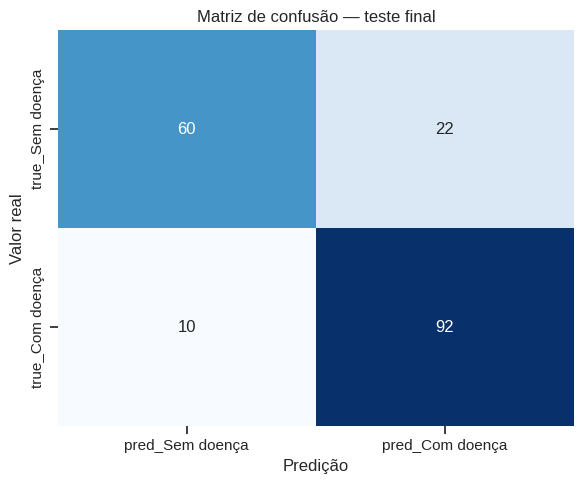

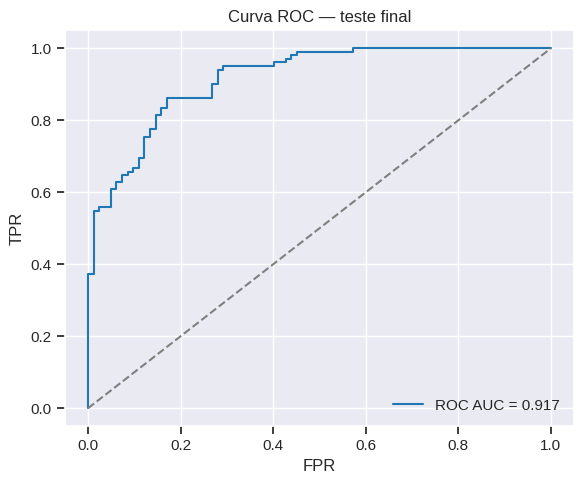

,test_value
accuracy,0.826087
precision,0.807018
recall,0.901961
f1,0.851852
balanced_accuracy,0.816834
roc_auc,0.917025


,pred_Sem doença,pred_Com doença
true_Sem doença,60,22
true_Com doença,10,92


,precision,recall,f1-score,support
Sem doença,0.857143,0.731707,0.789474,82.000000
Com doença,0.807018,0.901961,0.851852,102.000000
accuracy,0.826087,0.826087,0.826087,0.826087
macro avg,0.832080,0.816834,0.820663,184.000000
weighted avg,0.829356,0.826087,0.824053,184.000000


In [11]:
final_evaluation = evaluate_classifier(
    best_model,
    X_test,
    y_test,
    pos_label=POS_LABEL,
    class_names=CLASS_NAMES,
)
final_metrics = final_evaluation["metrics"]
evaluation_artifacts = save_evaluation_artifacts(
    final_evaluation,
    y_test,
    ARTIFACTS_DIR,
    POS_LABEL,
)

display(pd.DataFrame([final_metrics]).T.rename(columns={0: "test_value"}))
display(final_evaluation["confusion_matrix"])
display(final_evaluation["classification_report"])

## 10. Importância de atributos

Para não voltar a consultar o teste, esta seção usa a importância Gini já aprendida pelo Random Forest. Os nomes consideram imputação, indicadores de ausência e seleção de atributos do pipeline vencedor.

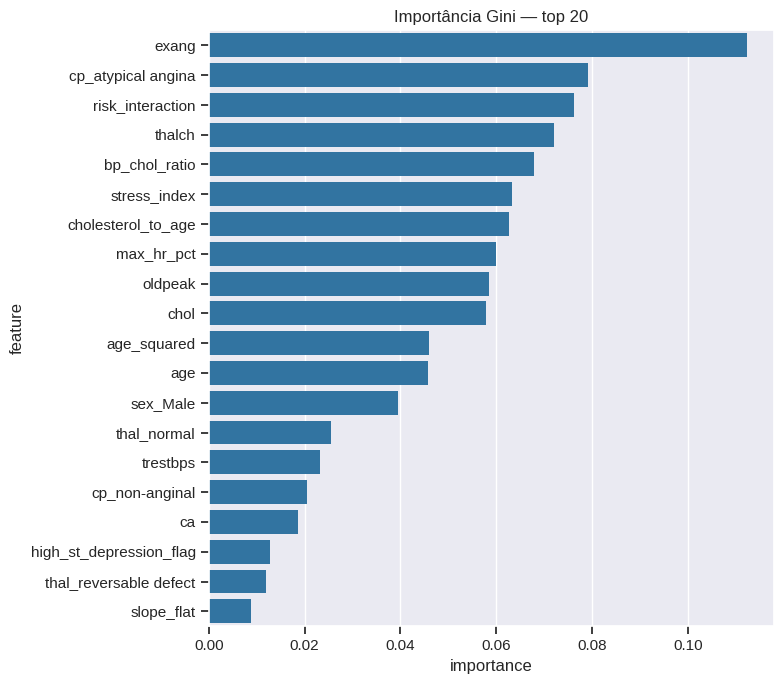

,feature,importance
0,exang,0.112396
1,cp_atypical angina,0.079223
2,risk_interaction,0.076259
3,thalch,0.072164
4,bp_chol_ratio,0.067998
5,stress_index,0.063336
6,cholesterol_to_age,0.062665
7,max_hr_pct,0.059995
8,oldpeak,0.058513
9,chol,0.057959


In [12]:
def extract_feature_importance(
    fitted_pipeline: Pipeline,
    input_features: pd.Index,
) -> pd.DataFrame:
    """Relaciona as importâncias do modelo aos atributos após preprocessing."""
    preprocessor = fitted_pipeline.named_steps["preprocess"]
    model = fitted_pipeline.named_steps["model"]
    if not hasattr(model, "feature_importances_"):
        return pd.DataFrame(columns=["feature", "importance"])
    feature_names = preprocessor.get_feature_names_out(input_features)
    if len(feature_names) != len(model.feature_importances_):
        raise RuntimeError("Quantidade de nomes e importâncias não coincide.")
    return (
        pd.DataFrame(
            {
                "feature": feature_names,
                "importance": model.feature_importances_,
            }
        )
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )


feature_importance_df = extract_feature_importance(best_model, X_train.columns)
feature_importance_path = ARTIFACTS_DIR / "feature_importance.csv"
feature_importance_df.to_csv(feature_importance_path, index=False)
feature_artifacts = [feature_importance_path]

if not feature_importance_df.empty:
    top_features = feature_importance_df.head(20)
    figure, axis = plt.subplots(figsize=(8, max(5, 0.35 * len(top_features))))
    sns.barplot(data=top_features, x="importance", y="feature", color="#1f77b4", ax=axis)
    axis.set_title("Importância Gini — top 20")
    figure.tight_layout()
    feature_plot_path = ARTIFACTS_DIR / "feature_importance_top20.png"
    figure.savefig(feature_plot_path, dpi=160, bbox_inches="tight")
    feature_artifacts.append(feature_plot_path)
    plt.show()
    plt.close(figure)
    display(top_features)

## 11. Persistência segura e registro no MLflow

O formato principal é `.skops`, que permite inspecionar tipos desconhecidos antes do carregamento. A cópia Joblib é opcional e existe apenas por compatibilidade didática — arquivos Joblib/Pickle nunca devem ser carregados de fonte não confiável.

O MLflow é importado e executado somente neste processo principal, depois que o treinamento distribuído terminou. O tracking URI padrão usa SQLite em `mlflow.db`, com artefatos em `mlflow-artifacts/`; para um servidor, defina `MLFLOW_TRACKING_URI` antes de iniciar o kernel.

In [13]:
def sha256_file(path: Path) -> str:
    """Calcula o SHA-256 de um artefato persistido."""
    digest = hashlib.sha256()
    with path.open("rb") as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


def save_model_safely(
    model: Pipeline,
    models_dir: Path,
    save_joblib_copy: bool,
) -> tuple[dict[str, Path], Path, list[str]]:
    """Persiste com skops de forma atômica e gera checksums de integridade."""
    models_dir.mkdir(parents=True, exist_ok=True)
    saved_paths: dict[str, Path] = {}

    skops_path = models_dir / "best_model.skops"
    skops_tmp = models_dir / ".best_model.skops.tmp"
    try:
        sio.dump(model, skops_tmp)
        skops_tmp.replace(skops_path)
    finally:
        skops_tmp.unlink(missing_ok=True)
    saved_paths["skops"] = skops_path

    if save_joblib_copy:
        joblib_path = models_dir / "best_model.joblib"
        joblib_tmp = models_dir / ".best_model.joblib.tmp"
        try:
            joblib.dump(model, joblib_tmp)
            joblib_tmp.replace(joblib_path)
        finally:
            joblib_tmp.unlink(missing_ok=True)
        saved_paths["joblib"] = joblib_path

    untrusted_types = sio.get_untrusted_types(file=skops_path)
    manifest = {
        "files": {
            name: {
                "path": str(path),
                "sha256": sha256_file(path),
                "bytes": path.stat().st_size,
            }
            for name, path in saved_paths.items()
        },
        "skops_untrusted_types_to_review_before_loading": untrusted_types,
    }
    manifest_path = models_dir / "model_manifest.json"
    manifest_path.write_text(
        json.dumps(manifest, indent=2, ensure_ascii=False),
        encoding="utf-8",
    )
    return saved_paths, manifest_path, untrusted_types


def log_experiment_mlflow(
    model: Pipeline,
    search: RandomizedSearchCV,
    cv_results: pd.DataFrame,
    final_metrics: dict[str, float | None],
    search_duration_seconds: float,
    artifact_paths: list[Path],
    model_paths: dict[str, Path],
    model_manifest_path: Path,
    input_example: pd.DataFrame,
    distributed_mode: bool,
    worker_count: int,
    cluster_total_threads: int,
) -> str:
    """Registra parâmetros, métricas, relatórios e o pipeline no processo principal."""
    # Import tardio: MLflow/requests/urllib3 não entram nas tarefas serializadas aos workers.
    import mlflow
    import mlflow.sklearn
    from mlflow.models import infer_signature

    mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
    if MLFLOW_TRACKING_URI == DEFAULT_MLFLOW_TRACKING_URI:
        tracking_client = mlflow.MlflowClient()
        if tracking_client.get_experiment_by_name(EXPERIMENT_NAME) is None:
            tracking_client.create_experiment(
                EXPERIMENT_NAME,
                artifact_location=MLFLOW_ARTIFACTS_DIR.as_uri(),
            )
    mlflow.set_experiment(EXPERIMENT_NAME)

    with mlflow.start_run(run_name=RUN_NAME) as run:
        run_params = {
            "random_state": RANDOM_STATE,
            "test_size": TEST_SIZE,
            "cv_strategy": "RepeatedStratifiedKFold",
            "cv_n_splits": N_SPLITS,
            "cv_n_repeats": N_REPEATS,
            "search_budget": SEARCH_BUDGET,
            "n_candidates": len(cv_results),
            "planned_cv_fits": TOTAL_CV_FITS,
            "scoring": SCORING,
            "positive_label": POS_LABEL,
            "execution_mode": "dask" if distributed_mode else "local_fallback",
            "dask_scheduler": DASK_SCHEDULER,
            "dask_workers": worker_count,
            "dask_total_threads": cluster_total_threads,
            "local_n_jobs_fallback": LOCAL_N_JOBS,
            **{f"best_{key}": value for key, value in search.best_params_.items()},
            **{f"version_{key}": value for key, value in local_versions().items()},
        }
        mlflow.log_params({key: str(value) for key, value in run_params.items()})
        mlflow.log_metric("best_cv_score", float(search.best_score_))
        mlflow.log_metric("search_duration_seconds", float(search_duration_seconds))
        for metric_name, metric_value in final_metrics.items():
            if metric_value is not None and np.isfinite(metric_value):
                mlflow.log_metric(f"test_{metric_name}", float(metric_value))

        for artifact_path in artifact_paths:
            if artifact_path.is_file():
                mlflow.log_artifact(str(artifact_path), artifact_path="reports")
        for model_path in model_paths.values():
            mlflow.log_artifact(str(model_path), artifact_path="persisted_models")
        mlflow.log_artifact(str(model_manifest_path), artifact_path="persisted_models")

        signature = infer_signature(input_example, model.predict(input_example))
        mlflow.sklearn.log_model(
            model,
            name="model",
            signature=signature,
            input_example=input_example,
            serialization_format="skops",
            skops_trusted_types=SKOPS_TRUSTED_TYPES,
        )
        return run.info.run_id

In [14]:
model_paths, model_manifest_path, skops_untrusted_types = save_model_safely(
    best_model,
    MODELS_DIR,
    SAVE_JOBLIB_COPY,
)
if skops_untrusted_types:
    logger.warning(
        "Revise estes tipos antes de carregar o .skops: %s",
        skops_untrusted_types,
    )

local_versions_path = ARTIFACTS_DIR / "local_versions.json"
local_versions_path.write_text(
    json.dumps(local_versions(), indent=2, ensure_ascii=False),
    encoding="utf-8",
)

all_artifacts = [
    search_results_path,
    ARTIFACTS_DIR / "cluster_versions.csv",
    local_versions_path,
    *evaluation_artifacts,
    *feature_artifacts,
]
diagnostic_path = ARTIFACTS_DIR / "cluster_diagnostic.csv"
if diagnostic_path.is_file() and RUN_CLUSTER_DIAGNOSTIC:
    all_artifacts.append(diagnostic_path)

try:
    mlflow_run_id = log_experiment_mlflow(
        best_model,
        search,
        cv_results_df,
        final_metrics,
        search_duration_seconds,
        all_artifacts,
        model_paths,
        model_manifest_path,
        X_train.head(5).astype("float64"),
        distributed_mode,
        worker_count,
        cluster_total_threads,
    )
    logger.info("Execução registrada no MLflow: run_id=%s", mlflow_run_id)
except Exception:
    logger.exception(
        "Falha no registro MLflow. Os modelos e relatórios locais foram preservados."
    )
    mlflow_run_id = None

display(
    pd.DataFrame(
        {
            "artifact": [*model_paths.keys(), "manifest", "cv_results", "mlflow_run_id"],
            "location": [
                *[str(path) for path in model_paths.values()],
                str(model_manifest_path),
                str(search_results_path),
                mlflow_run_id,
            ],
        }
    )
)

2026-07-15 20:40:11,971 | WARNING | Revise estes tipos antes de carregar o .skops: ['numpy.dtype', 'sklearn.feature_selection._univariate_selection.f_classif']
2026-07-15 20:40:22,750 | INFO | Execução registrada no MLflow: run_id=e193128d223549c5b9546cb2ac96932e


,artifact,location
0,skops,/home/carloslessa/FCD/POSTECH/modulo-extra/01-...
1,joblib,/home/carloslessa/FCD/POSTECH/modulo-extra/01-...
2,manifest,/home/carloslessa/FCD/POSTECH/modulo-extra/01-...
3,cv_results,/home/carloslessa/FCD/POSTECH/modulo-extra/01-...
4,mlflow_run_id,e193128d223549c5b9546cb2ac96932e


## 12. Verificação e reuso

Orçamentos disponíveis:

```bash
# 25 candidatos: validação rápida
MODEL_SEARCH_BUDGET=quick jupyter lab

# 500 candidatos: padrão distribuído
MODEL_SEARCH_BUDGET=extended jupyter lab

# 1.000 candidatos: busca longa
MODEL_SEARCH_BUDGET=exhaustive jupyter lab

# Sobrescreve diretamente o número de candidatos
MODEL_SEARCH_N_ITER=750 jupyter lab
```

Para confirmar a distribuição:

1. verifique que a tabela do cluster contém a quantidade de workers e threads definida para o teste; a topologia documentada soma 20, mas a execução armazenada registrou 48;
2. abra o dashboard durante `search.fit` e observe tarefas em vários workers;
3. ative `MODEL_RUN_CLUSTER_DIAGNOSTIC=1`, reinicie o kernel e confira os hosts/PIDs retornados;
4. confirme nos logs dos workers que tarefas foram recebidas.

Para abrir a interface local do MLflow no host principal:

```bash
source .venv/bin/activate
mlflow ui --backend-store-uri sqlite:///mlflow.db --host 127.0.0.1 --port 5000
```

Para carregar o `.skops`, primeiro revise a lista de tipos desconhecidos; só então autorize explicitamente os tipos considerados seguros:

```python
import skops.io as sio

path = MODELS_DIR / "best_model.skops"
unknown_types = sio.get_untrusted_types(file=path)
print(unknown_types)  # revisão humana obrigatória
restored_model = sio.load(path, trusted=unknown_types)
```

Limitações operacionais: o cluster usa TCP sem TLS/autenticação e deve permanecer restrito à LAN confiável; os IPs são fixos na configuração; resultados exatos podem variar se versões, número de candidatos ou scoring forem alterados. O fallback local limita os jobs, mas os perfis `extended` e `exhaustive` continuam caros; prefira `quick` ou `standard` sem o cluster.